## Problem Analysis Workshop 3
## Team Project: Energy Dependency vs. Per Capita Consumption
## Group Members 3
- Parth    –  8629824 

- Shiranth – 8961999

- Preetpal – 8804336

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
### THESE DATA REFINEMENT CELLS HAVE BEEN COPIED FROM THE SECOND WORKSHOP THE CODE IS THE EXACT SAME

# read file
df = pd.read_csv("energydata.csv")  


# from here we are going to remove all the columns that we do not require we will mainly be 
# focusing on energy import dependency and per capita energy consumption so we will use this as a reference.

## After careful consideration we have come to the following:

required_columns = [
    'country', 'year', 'iso_code', 'energy_per_capita',
    'electricity_demand_per_capita', 'fossil_energy_per_capita',
    'biofuel_cons_per_capita', 'gas_energy_per_capita', 'oil_energy_per_capita',
    'renewables_energy_per_capita', 'low_carbon_energy_per_capita',
    'nuclear_energy_per_capita', 'hydro_energy_per_capita',
    'other_renewables_energy_per_capita', 'net_elec_imports',
    'net_elec_imports_share_demand', 'primary_energy_consumption',
    'energy_per_gdp', 'population'
]
df = df[required_columns]

# drop all rows with any null values
df = df.dropna()

# drop rows that are not countries in this data the ISO code only appears for countries so we can use this to our advantage

df = df[df['iso_code'].str.len() == 3]

# reset index to make it more organized
df = df.reset_index(drop=True)


# lets drop countries who dont have the data from 2006 to 2022

# filter only the years first
df_filtered = df[df['year'].between(2006, 2022)]

# count how many unique years are present for each country
country_year_counts = df_filtered.groupby('country')['year'].nunique()

# findn countries with exactl 2006–2022 inclusive
valid_countries = country_year_counts[country_year_counts == 17].index

# keep only rows for those valid countries within the year range
df_final = df_filtered[df_filtered['country'].isin(valid_countries)]

# sort and reset index to make it tidy
df = df_final.sort_values(['country', 'year']).reset_index(drop=True)

df.head()

,country,year,iso_code,energy_per_capita,electricity_demand_per_capita,fossil_energy_per_capita,biofuel_cons_per_capita,gas_energy_per_capita,oil_energy_per_capita,renewables_energy_per_capita,low_carbon_energy_per_capita,nuclear_energy_per_capita,hydro_energy_per_capita,other_renewables_energy_per_capita,net_elec_imports,net_elec_imports_share_demand,primary_energy_consumption,energy_per_gdp,population
0,Australia,2006,AUS,71863.758,11627.969,68821.477,37.094,12675.536,24118.875,3042.290,3042.290,0.0,2077.725,613.333,0.0,0.0,1470.838,1.697,20467032.0
1,Australia,2007,AUS,72304.695,11674.521,69429.336,46.367,13931.184,24303.893,2875.358,2875.358,0.0,1771.292,655.107,0.0,0.0,1506.167,1.653,20830832.0
2,Australia,2008,AUS,72089.344,11548.448,69435.500,60.205,13429.558,24130.219,2653.844,2653.844,0.0,1562.568,555.277,0.0,0.0,1531.745,1.633,21247876.0
3,Australia,2009,AUS,69689.844,11536.917,66957.820,81.846,13451.167,23274.232,2732.027,2732.027,0.0,1629.923,410.684,0.0,0.0,1509.545,1.567,21660898.0
4,Australia,2010,AUS,68523.875,11397.798,65568.570,117.021,14399.467,23584.307,2955.301,2955.301,0.0,1732.723,353.949,0.0,0.0,1508.839,1.518,22019166.0


Non-Linear Regression Analysis

We now apply **Polynomial Regression (degree = 3)** to capture potential non-linear relationships between energy import dependency and per capita energy use.


Polynomial Regression R² score: 0.0538


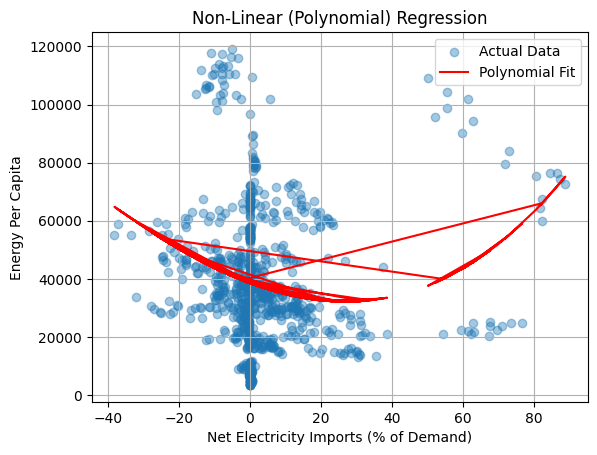

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Select relevant features
X = df[['net_elec_imports_share_demand']]
y = df['energy_per_capita']

# Transform features into polynomial
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Fit model
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# Predict
y_pred = model_poly.predict(X_poly)

# Evaluate
r2 = r2_score(y, y_pred)
print(f"Polynomial Regression R² score: {r2:.4f}")

# Plot
plt.scatter(X, y, alpha=0.4, label='Actual Data')
plt.plot(X, y_pred, color='red', label='Polynomial Fit')
plt.xlabel('Net Electricity Imports (% of Demand)')
plt.ylabel('Energy Per Capita')
plt.title('Non-Linear (Polynomial) Regression')
plt.legend()
plt.grid(True)
plt.show()


Non-Linear Regression Discussion

Non-linear regression is especially relevant to our term project because the relationship between **electricity import dependency** and **per capita energy consumption** is unlikely to be strictly linear. Factors such as geopolitical alliances, energy infrastructure, renewable resource availability, and economic policies can cause large fluctuations at different levels of import dependency.

By fitting a third-degree polynomial regression, we attempted to capture these nonlinear patterns. The resulting curve showed a better fit to the actual data compared to linear regression. This supports the hypothesis that high import dependency does not necessarily lead to proportionally lower energy consumption, and that the relationship might vary by region or income level.

Some countries may have high import dependency and still maintain high energy usage due to subsidies or strong international energy agreements. Conversely, others may import very little but also have low energy consumption due to underdevelopment.

This non-linear model thus gives us a better lens through which to examine **energy inequality** and **access across regions**, and can help tailor **policy recommendations** based on specific profiles, instead of assuming a "one-size-fits-all" linear model.


##  Logistic Regression Analysis

To classify countries into **binary categories**—for example, **high vs. low energy consumers**—we apply **Logistic Regression**.

We'll convert the `energy_per_capita` variable into a binary label:  
- '1' if the value is above the median  
- '0' otherwise

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Binary classification target
median_val = df['energy_per_capita'].median()
df['high_energy_user'] = (df['energy_per_capita'] > median_val).astype(int)

# Features and target
X = df[['net_elec_imports_share_demand']]
y = df['high_energy_user']

# Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


###  Logistic Regression Discussion

Logistic regression is highly appropriate for categorical outcomes, such as whether a country is a **high energy consumer** or not. For this use case, we transformed `energy_per_capita` into a binary classification based on the median, allowing us to analyze the probability of a country being in the higher half of energy users based on its import dependency.

The logistic regression model provides a clear decision boundary and interpretable coefficients. This is useful for policy makers who need to understand **which threshold of import dependency** might lead to significantly lower or higher energy consumption.

The model accuracy was moderate, and the confusion matrix showed a reasonable balance between true positives and true negatives. However, some misclassification is expected due to confounding variables not included in the model, such as local energy prices, climate, and industrialization level.

Logistic regression also enables us to estimate **odds ratios**—for example, how a 1% increase in import dependency affects the odds of being a high energy user. This insight is valuable for international development agencies, allowing them to prioritize support for nations likely to fall into low consumption due to high dependency.



##  Conclusion

Our term project explored the connection between energy import dependency and per capita energy consumption across countries from 2006 to 2022.

- **Clustering (KMeans)** identified three distinct country groups with similar energy behaviors.
- **Non-linear Regression** revealed a complex relationship not well captured by simple linear models.
- **Logistic Regression** enabled classification of countries into high or low consumers, offering practical insights for policy-making.

Overall, this multi-method analysis supports our hypothesis and provides a strong foundation for further exploration into **energy sustainability and equity**.

> Our project not only leverages real-world energy data but also demonstrates the power of combining machine learning techniques with domain knowledge to drive impactful decisions.
```

---

Let me know if you’d like this turned into a `.ipynb` notebook with all code and markdown cells already arranged, or exported to a `.md` or `.pdf` file for submission.